# DiT Next-Frame Prediction Evaluation

Loads a trained DiT checkpoint, runs `rollout()` on a DROID val sample with GT actions,
and visualizes predicted vs GT next frames using SH→RGB color extraction.

In [1]:
import os, sys
sys.path.insert(0, os.path.expandvars("$GWM_PATH"))
import torch, numpy as np, matplotlib.pyplot as plt
from hydra import compose, initialize
from hydra.core.global_hydra import GlobalHydra

In [2]:
GWM_PATH = os.environ["GWM_PATH"]

GlobalHydra.instance().clear()
with initialize(config_path="../configs", version_base=None):
    cfg = compose(config_name="train_gwm", overrides=[
        "world_model.observation.use_gs=true",
        "world_model.reward.use_reward_model=false",
        "world_model.vae.use_vae=false",
        f"dataset.data_path={GWM_PATH}/data/",
    ])

print("Config loaded. context_length:", cfg.world_model.context_length)

Config loaded. context_length: 2


In [3]:
from gaussianwm.gwm_predictor import GaussianPredictor

CKPT = f"{GWM_PATH}/logs/gwm/checkpoints/model_latest.pt"
model = GaussianPredictor(cfg.world_model).cuda()
state_dict = torch.load(CKPT, map_location="cuda")
model.model.load_state_dict(state_dict)
model.eval()
print(f"Loaded DiT from {CKPT}")

/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-20 11:51:48.167474: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-20 11:51:48.167500: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-20 11:51:48.168177: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-20 11:51:48.172177: I tensorflow/core/platform/cpu_feature_guard.cc:182] This

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(

🔥🔥🔥 Splatt3r Model loaded from /home/frankcholula/Workspace/gaussianwm/third_party/splatt3r/checkpoints/splatt3r_v1.0/epoch=19-step=1200.ckpt
[Model] Trainable parameters: 33.205088M
[Model] Total parameters: 33.598304M


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/frankcholula/Workspace/gaussianwm/gaussianwm/vq_model/lpips.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickli

loaded pretrained LPIPS loss from /home/frankcholula/Workspace/gaussianwm/ckpt/lpips/vgg.pth
Loaded DiT from /home/frankcholula/Workspace/gaussianwm/logs/gwm/checkpoints/model_latest.pt


In [4]:
from gaussianwm.processor.datasets import build_gaussian_splatting_reconstruction_dataset

val_dataset = build_gaussian_splatting_reconstruction_dataset("val", cfg.dataset)
obs, action, reward = next(iter(val_dataset))
# obs:    [T, H, W, 3]  uint8,  T=segment_length (10)
# action: [T, 10]       float
print(f"obs: {obs.shape} {obs.dtype}, action: {action.shape}")

2026-02-20 11:52:07.121509: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-20 11:52:07.123501: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-20 11:52:07.306011: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


Loading existing dataset statistics from /home/frankcholula/Workspace/gaussianwm/data/droid_100/1.0.0/dataset_statistics_a1db6f7c9761e0c1120da4648c2200f575f382544cdf98b0b8587752b44cacc0.json.


2026-02-20 11:52:08.367384: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization



######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# droid_100: ===============================================================1.000000 #
######################################################################################

Threads per Dataset: %s [48]
Reads per Dataset: %s [48]
Constructing datasets...


2026-02-20 11:52:08.868918: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


Applying frame transforms on dataset...


/home/frankcholula/Workspace/gaussianwm/gaussianwm/processor/datasets.py:249: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  left_frames = torch.from_numpy(left_frames)


obs: torch.Size([10, 128, 128, 3]) torch.uint8, action: torch.Size([24, 10])


In [5]:
HORIZON = 8  # predict 8 future frames

# Stack first 2 RGB frames as [1, 6, H, W] in [0, 255] float
# rollout() divides by 255 internally
context = obs[:2].permute(0, 3, 1, 2).float()      # [2, 3, H, W]
obs_input = context.reshape(1, -1, 128, 128).cuda() # [1, 6, 128, 128]

# GT actions for the predicted steps
gt_actions = action[2:2+HORIZON].float().cuda()     # [8, 10]

def gt_policy(obs_t, t):
    return gt_actions[t].unsqueeze(0)  # [1, 10]

with torch.no_grad():
    rollout_obs, rollout_actions, rollout_rewards = model.rollout(
        obs_input, policy=gt_policy, horizon=HORIZON
    )
# rollout_obs: [1, HORIZON+1, 28, 128, 128]
print(f"rollout_obs: {rollout_obs.shape}")
assert rollout_obs.shape == (1, HORIZON + 1, 28, 128, 128), \
    f"Unexpected shape: {rollout_obs.shape}"

rollout_obs: torch.Size([1, 9, 28, 128, 128])


In [6]:
C0 = 0.28209479177387814

def gauss_to_rgb(gauss_14hw):
    """[14, H, W] tensor → [H, W, 3] numpy RGB in [0, 1]"""
    sh = gauss_14hw[10:13]  # [3, H, W] SH DC coefficients
    rgb = (0.5 + C0 * sh).clamp(0, 1)
    return rgb.permute(1, 2, 0).cpu().numpy()

def gt_frame_rgb(obs_thwc, t):
    """Raw uint8 GT frame at time t → [H, W, 3] numpy in [0, 1]"""
    return obs_thwc[t].float().numpy() / 255.

In [7]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnrs, ssims = [], []
for t in range(HORIZON):
    gt_t = t + 2  # GT frame index in dataset (skip 2 context frames)
    gt_img = gt_frame_rgb(obs, gt_t)          # [H, W, 3] in [0, 1]

    pred_gauss = rollout_obs[0, t+1, 14:]     # [14, H, W] — newest context frame
    pred_img = gauss_to_rgb(pred_gauss)       # [H, W, 3] in [0, 1]

    p = psnr(gt_img, pred_img, data_range=1.0)
    s = ssim(gt_img, pred_img, data_range=1.0, channel_axis=2)
    psnrs.append(p)
    ssims.append(s)
    print(f"t={gt_t:2d}  PSNR={p:.2f} dB  SSIM={s:.4f}")

print(f"\nMean PSNR: {np.mean(psnrs):.2f} dB")
print(f"Mean SSIM: {np.mean(ssims):.4f}")

t= 2  PSNR=15.48 dB  SSIM=0.5625
t= 3  PSNR=14.16 dB  SSIM=0.4448
t= 4  PSNR=11.56 dB  SSIM=0.2870
t= 5  PSNR=9.82 dB  SSIM=0.1826
t= 6  PSNR=8.87 dB  SSIM=0.1395
t= 7  PSNR=8.87 dB  SSIM=0.1394
t= 8  PSNR=8.87 dB  SSIM=0.1394
t= 9  PSNR=8.87 dB  SSIM=0.1394

Mean PSNR: 10.81 dB
Mean SSIM: 0.2543


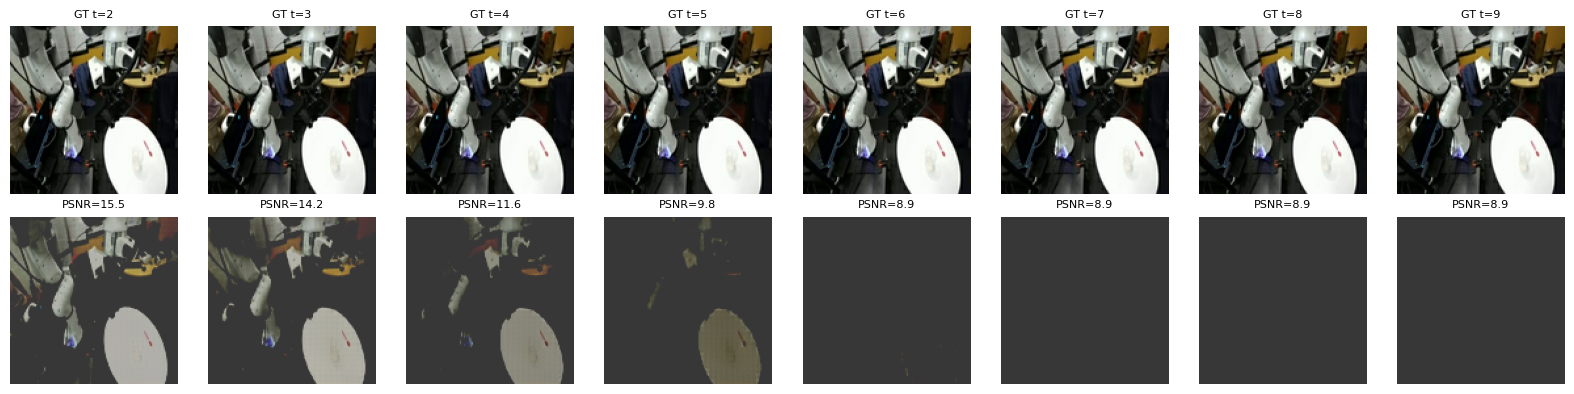

Saved to eval_rollout.png


In [ ]:
fig, axes = plt.subplots(2, HORIZON, figsize=(HORIZON * 2, 4))
for t in range(HORIZON):
    gt_t = t + 2
    gt_img = gt_frame_rgb(obs, gt_t)
    pred_gauss = rollout_obs[0, t+1, 14:]
    pred_img = gauss_to_rgb(pred_gauss)

    axes[0, t].imshow(gt_img)
    axes[0, t].set_title(f"GT t={gt_t}", fontsize=8)
    axes[0, t].axis("off")

    axes[1, t].imshow(pred_img)
    axes[1, t].set_title(f"PSNR={psnrs[t]:.1f}", fontsize=8)
    axes[1, t].axis("off")

axes[0, 0].set_ylabel("GT", fontsize=10)
axes[1, 0].set_ylabel("Pred (SH→RGB)", fontsize=10)
plt.tight_layout()
plt.savefig("eval_rollout.png", dpi=150)
plt.show()
print("Saved to eval_rollout.png")

In [9]:
dim_groups = {
    "XYZ":       (0,  3),
    "Scales":    (3,  6),
    "Rotations": (6,  10),
    "SH/Color":  (10, 13),
    "Opacity":   (13, 14),
}

# Build GT Gaussian features for the 8 predicted frames
gt_rgb_tensor = (
    obs[2:2+HORIZON]              # [8, H, W, 3] uint8
    .permute(0, 3, 1, 2)          # [8, 3, H, W]
    .float()
    .unsqueeze(0)                 # [1, 8, 3, H, W]
    .cuda()
)

with torch.no_grad():
    gt_gaussians = model._process_obs(gt_rgb_tensor / 255.)  # [1, 8, 14, H, W]

pred_gaussians = rollout_obs[0, 1:, 14:]  # [8, 14, H, W]

print(f"{'Property':<12}  MSE")
print("-" * 25)
for name, (s, e) in dim_groups.items():
    mse = ((pred_gaussians[:, s:e] - gt_gaussians[0, :, s:e]) ** 2).mean().item()
    print(f"{name:<12}: {mse:.6f}")

Property      MSE
-------------------------
XYZ         : 0.175528
Scales      : 0.000135
Rotations   : 0.000686
SH/Color    : 0.786092
Opacity     : 0.001369
